In [2]:
import numpy as np
# version: numpy 2.3.4
import matplotlib.pyplot as plt
# version: matplotlib 3.9.3
# from pathlib import Path

In [2]:
# td_path = Path.cwd().parent / "BHD noise time domain/test_1_12"    
# print(np.loadtxt(td_path/"3ma.csv", dtype=np.float64, delimiter=',')[:2, :2]), 

In [15]:
'''
for data measured by oscilloscope.
BW/MHz----------------index
   100----------------16001
'''
P_LO = np.array([0.01211, 0.072, 0.3, 0.546, 0.787, 1.035, 1.27, 1.51, 1.742, 1.98, 2.202, 2.442, 2.67, 2.89])

# electronic noise 
N_ele = np.full_like(P_LO, sum(np.power(np.loadtxt(f"test_1_22a/ele_noise.csv", dtype=np.float64, delimiter=',')[1:16001, 1], 2)))

# measured noise
N_m = np.zeros_like(P_LO)
for i in range(5, 19):
    N_m[i-5] = sum(np.power(np.loadtxt(f"test_1_22a/{i}ma.csv", dtype=np.float64, delimiter=',')[1:16001, 1], 2))

# quantum noise
N_q = N_m - N_ele

QCNR = N_q / N_ele
QCNR_dB = 10 * np.log10(QCNR)
print(f'QCNR:\n{QCNR}\n')
print(f'QCNR(in dB):\n{QCNR_dB}')

QCNR:
[0.04501035 0.17959615 0.81521829 1.38715681 2.06815236 2.70149668
 3.40631709 3.88306855 4.69803256 5.07728088 5.77900112 6.27144582
 6.91863773 7.55493498]

QCNR(in dB):
[-13.46687622  -7.45702979  -0.88726088   1.42125557   3.1558253
   4.31604438   5.32285074   5.89175058   6.71916022   7.0563119
   7.61852779   7.97367674   8.40020591   8.78230731]


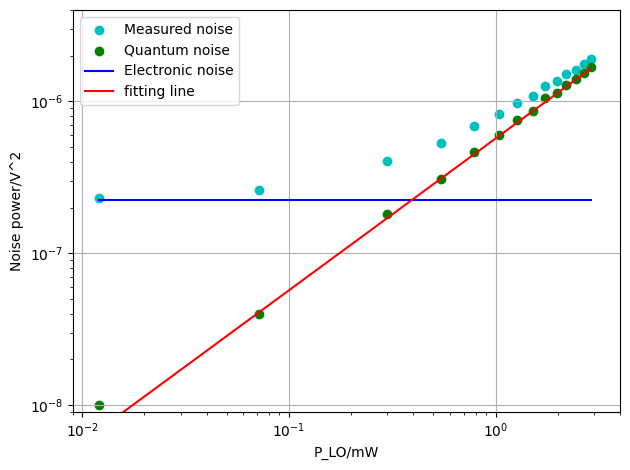

In [16]:
fig, ax = plt.subplots()
ax.scatter(P_LO, N_m, c='c', label='Measured noise')
ax.scatter(P_LO, N_q, c='g', label='Quantum noise')
ax.plot(P_LO, N_ele, c='b', label='Electronic noise')
ax.plot(P_LO, P_LO * 0.00000057, color='r', label='fitting line')
ax.legend()
ax.grid()
ax.set_xlabel('P_LO/mW')
ax.set_ylabel('Noise power/V^2')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(9e-3, 4)
ax.set_ylim(9e-9, 4e-6)
fig.tight_layout()
plt.show()

In [5]:
'''
for data measured by red pitaya.

the map from frequency to index (62.5MHz)
f/MHz--------index
 1------------133
 2------------264
10------------1312
20------------2624
25------------3278
'''

# LO power is the same.

# # esa noise
# f = np.loadtxt(f"test_1_21/sa_noise.csv", dtype=np.float64, delimiter=',')[1:, 1] / 10
# N_sa = np.full(16, sum(10 ** f))

# electronic noise power (including sa noise)
f = np.loadtxt(f"test_1_211/ele_noise.csv", dtype=np.float64, delimiter=',')[1:, 1] / 10
N_ele = np.full(16, sum(10 ** f))

# print(f'sa noise rate: {N_sa[0] / N_ele[0]}\n')

N_m = np.zeros(16)
for i in range(3, 19):
    f = np.loadtxt(f"test_1_211/{i}ma.csv", dtype=np.float64, delimiter=',')[1:, 1] / 10
    N_m[i-3] = sum(10 ** f)
N_q = N_m - N_ele

QCNR = N_q / N_ele
QCNR_dB = 10 * np.log10(QCNR)
print(f'QCNR:\n{QCNR}\n')
print(f'QCNR(in dB):\n{QCNR_dB}')

QCNR:
[-0.21009484 -0.07241828 -0.2020602   0.07468273  0.02819658  0.55041164
  0.69860006  0.98648843  1.28010205  1.3661178   1.68213002  2.02351209
  2.11270712  2.48871701  2.89225237  2.90144282]

QCNR(in dB):
[         nan          nan          nan -11.26779814 -15.49803571
  -2.59312389  -1.55771379  -0.05908006   1.07244592   1.35488151
   2.25859562   3.06105804   3.24839296   3.95975516   4.61236185
   4.62614016]


C:\Users\ztd\AppData\Local\Temp\ipykernel_15952\1791789787.py:30: RuntimeWarning: invalid value encountered in log10
  QCNR_dB = 10 * np.log10(QCNR)


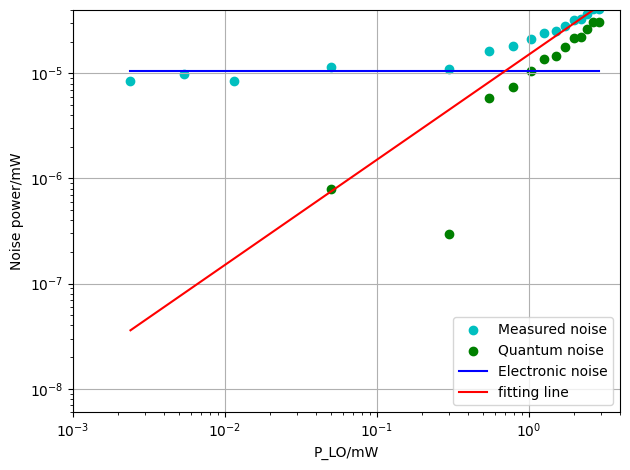

In [8]:
fig, ax = plt.subplots()
ax.scatter(P_LO, N_m, c='c', label='Measured noise')
ax.scatter(P_LO, N_q, c='g', label='Quantum noise')
ax.plot(P_LO, N_ele, c='b', label='Electronic noise')
ax.plot(P_LO, P_LO * 0.000015, color='r', label='fitting line')
ax.legend()
ax.grid()
ax.set_xlabel('P_LO/mW')
ax.set_ylabel('Noise power/mW')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(1e-3, 4)
# ax.set_ylim(N_q[1], N_m[-1]+0.00005)
ax.set_ylim(6e-9, 4e-5)
fig.tight_layout()
plt.show()